# Momepy roads - Viladecans

This notebook uses momepy to calculate geometrical and topological features of the Viladecans street network:
- **Street profile**: `width`, `openness`, `width_deviation` (requires OSM buildings)
- **Betweenness centrality** (node-based, local radius 500 m, propagated to edges via mean_nodes)
- **Closeness centrality** -- extended local (radius 800 m) and local 400 m
- **Straightness centrality** (node-based, radius 500 m)

Input: `VIL_noise_streets.gpkg` -- the Viladecans OSM drive streets with acoustic zone noise classes.

Local-radius variants are used for tractability, matching the Berlin pipeline.

## Import libraries

In [1]:
import os
import momepy as mm
import geopandas as gpd
import osmnx as ox
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

## Import streets segments

In [2]:
_layers_dir = os.path.join(os.path.dirname(os.path.abspath(os.getcwd())), 'layers')
edges = gpd.read_file(os.path.join(_layers_dir, 'VIL_noise_streets.gpkg'))
print(edges.crs)
print(edges.shape)
print(edges.columns.tolist())
print('Number of street segments:', len(edges))

EPSG:25831
(1613, 12)
['segment_id', 'highway', 'name', 'length', 'db_day', 'db_evening', 'db_night', 'noise_day', 'noise_evening', 'noise_night', 'distance', 'geometry']
Number of street segments: 1613


C:\Users\giofo\miniconda3\envs\data-encoding\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


In [3]:
place_name = 'Viladecans, Spain'
tags = {'building': True}

print('Downloading buildings from OSM...')
try:
    buildings = ox.features_from_place(place_name, tags)
except AttributeError:
    buildings = ox.geometries_from_place(place_name, tags)

print(f'Downloaded {len(buildings)} buildings.')
buildings = buildings[buildings.geometry.type.isin(['Polygon', 'MultiPolygon'])]
buildings = buildings.to_crs(edges.crs)
print(f'Polygon buildings: {len(buildings)}')

Downloaded 4111 buildings.
Polygon buildings: 4111


## Create Momepy street profile

In [4]:
profile = mm.street_profile(edges, buildings)
profile.head()

,width,openness,width_deviation
0,35.176945,0.590909,4.046847
1,50.000000,1.000000,NaN
2,50.000000,1.000000,NaN
3,50.000000,1.000000,NaN
4,50.000000,1.000000,NaN


In [5]:
edges[profile.columns] = profile
edges[profile.columns].head()

,width,openness,width_deviation
0,35.176945,0.590909,4.046847
1,50.000000,1.000000,NaN
2,50.000000,1.000000,NaN
3,50.000000,1.000000,NaN
4,50.000000,1.000000,NaN


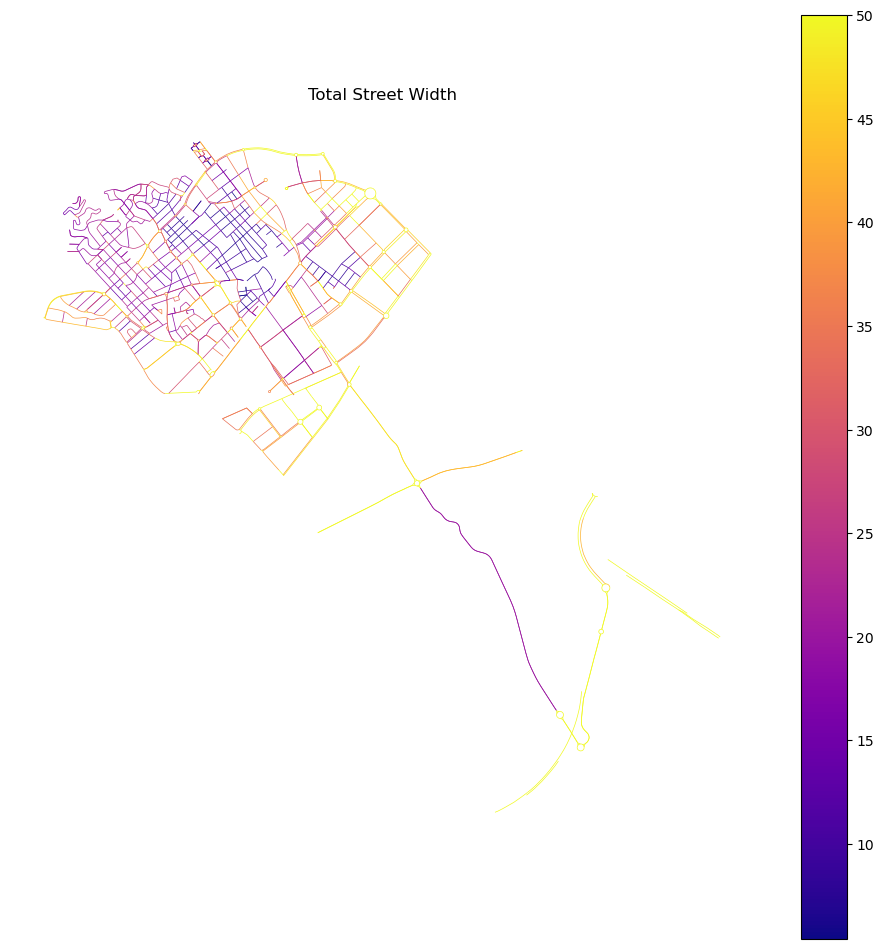

In [6]:
ax = edges.plot(cmap='plasma', column='width', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Total Street Width')
ax.set_axis_off()

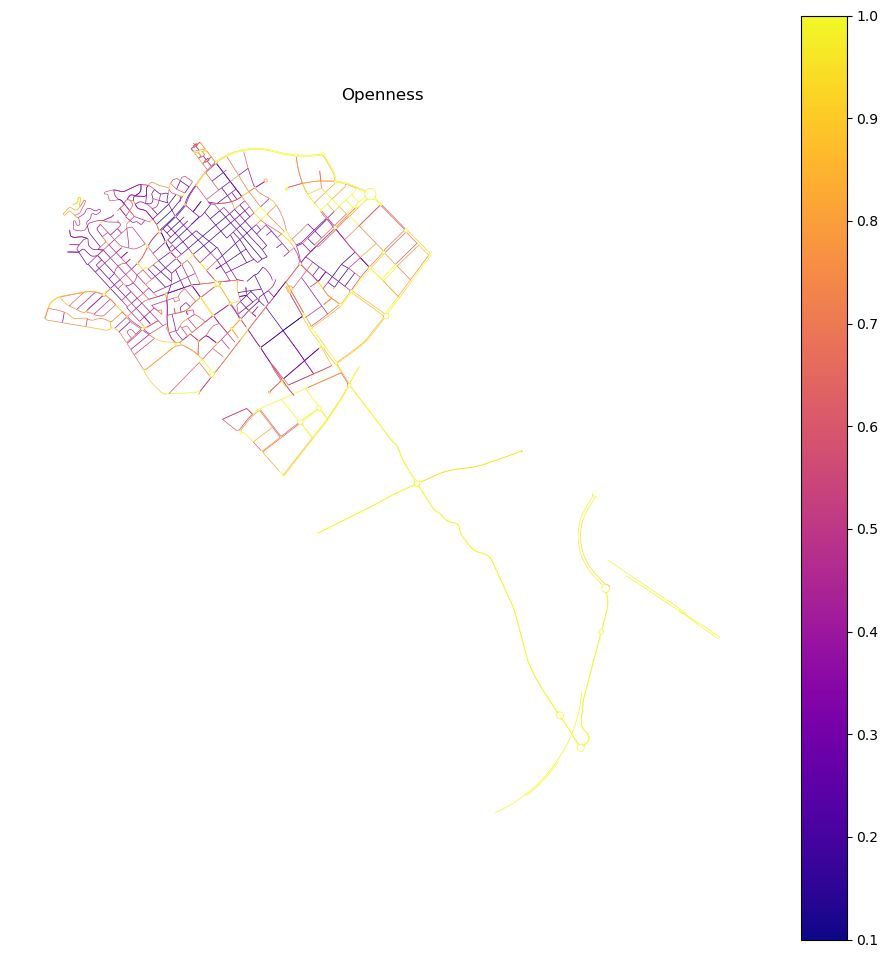

In [7]:
ax = edges.plot(cmap='plasma', column='openness', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Openness')
ax.set_axis_off()

# Centrality

Build the primal graph once; all centrality functions operate on it.

In momepy 0.11 all centralities are node-based. `mm.mean_nodes()` propagates each
node attribute to its incident edges (mean of the two endpoint values) before the
edge GeoDataFrame is extracted.

In [8]:
primal = mm.gdf_to_nx(edges, approach="primal")
print('Graph nodes:', primal.number_of_nodes(), '  edges:', primal.number_of_edges())

Graph nodes: 933   edges: 1613


## Betweenness Centrality

In [9]:
betweenness = mm.betweenness_centrality(
    primal, name='betweenness_metric_e', mode='edges', weight='mm_len',
)

In [10]:
primal_gdf_betw = mm.nx_to_gdf(betweenness, points=False)
primal_gdf_betw.head()

,segment_id,highway,name,length,db_day,db_evening,db_night,noise_day,noise_evening,noise_night,distance,geometry,width,openness,width_deviation,mm_len,betweenness_metric_e
0,206378333_6315715548_0,residential,"['Camí de la Via', 'Passatge de les Feixes Roca']",308.730134,68,65,61,3,3,3,381.651447,"LINESTRING (417459.73 4573025.45, 417476.559 4...",35.176945,0.590909,4.046847,309.140437,0.002059
1,6315715548_206378333_0,residential,"['Camí de la Via', 'Passatge de les Feixes Roca']",308.730134,68,65,61,3,3,3,381.651447,"LINESTRING (417727.694 4573070.599, 417675.592...",35.402010,0.575758,4.142431,309.140437,0.002059
2,2383446335_206378333_0,residential,Carrer de l'Enginy,167.878854,68,65,61,3,3,3,399.309198,"LINESTRING (417593.203 4572924.851, 417587.219...",34.320234,0.600000,0.181410,168.031053,0.000046
3,4469422084_6315715548_0,residential,Carrer d'Hipàcia,67.335323,70,67,61,4,3,3,358.633354,"LINESTRING (417780.484 4573112.116, 417775.314...",50.000000,1.000000,NaN,67.386480,0.008186
4,6315715548_2383446364_0,residential,Carrer d'Hipàcia,189.132682,70,67,61,4,3,3,484.608105,"LINESTRING (417727.694 4573070.599, 417704.878...",37.381258,0.545455,2.855489,189.139324,0.004087


Text(0.5, 1.0, 'Betweenness Centrality - Edge Mean (r=500 m)')

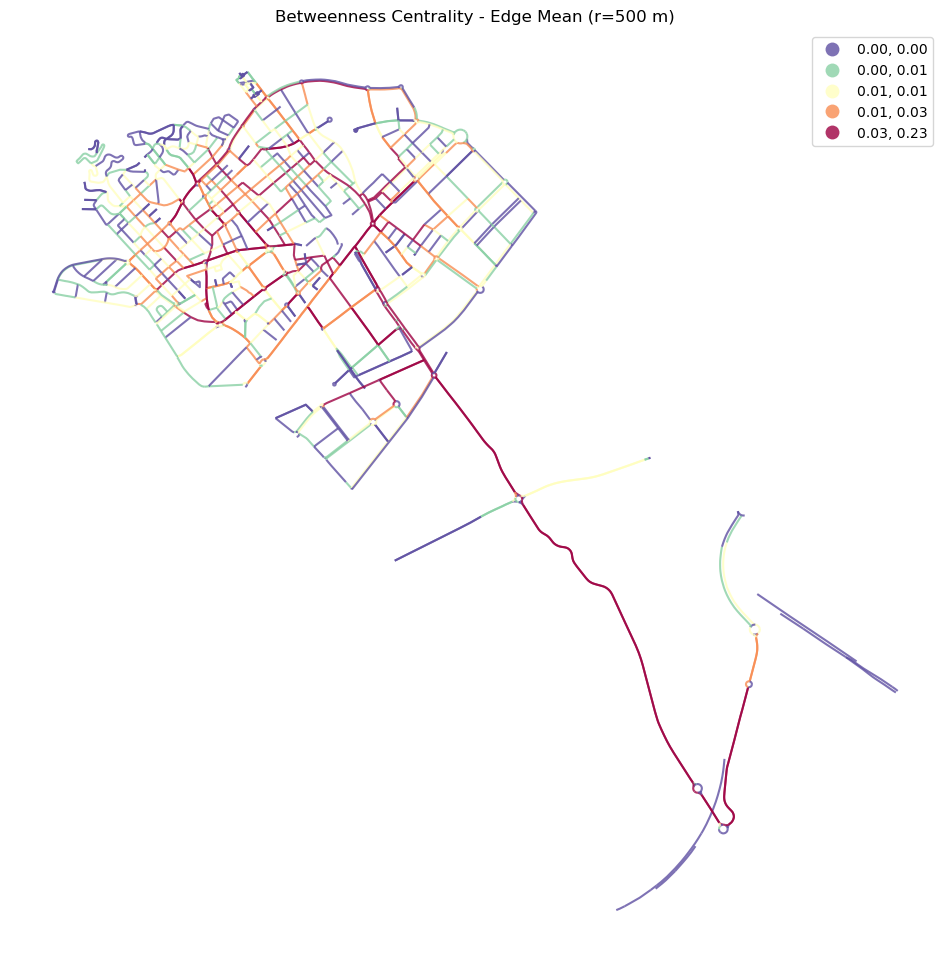

In [11]:
ax = primal_gdf_betw.plot(
    column='betweenness_metric_e',
    cmap='Spectral_r',
    scheme='quantiles',
    alpha=0.8,
    legend=True,
    figsize=(12, 12)
)
ax.set_axis_off()
ax.set_title('Betweenness Centrality - Edge Mean (r=500 m)')

## Global Closeness Centrality

Careful, takes a few minutes

In [12]:
closeness = mm.closeness_centrality(
    primal, name='closeness_global', weight='mm_len'
)

In [13]:
nodes = mm.nx_to_gdf(closeness, lines=False)
nodes.head()
nodes.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 933 entries, 0 to 932
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   x                 933 non-null    float64 
 1   y                 933 non-null    float64 
 2   closeness_global  933 non-null    float64 
 3   nodeID            933 non-null    int64   
 4   geometry          933 non-null    geometry
dtypes: float64(3), geometry(1), int64(1)
memory usage: 36.6 KB


Text(0.5, 1.0, 'Closenness Global (Node Based)')

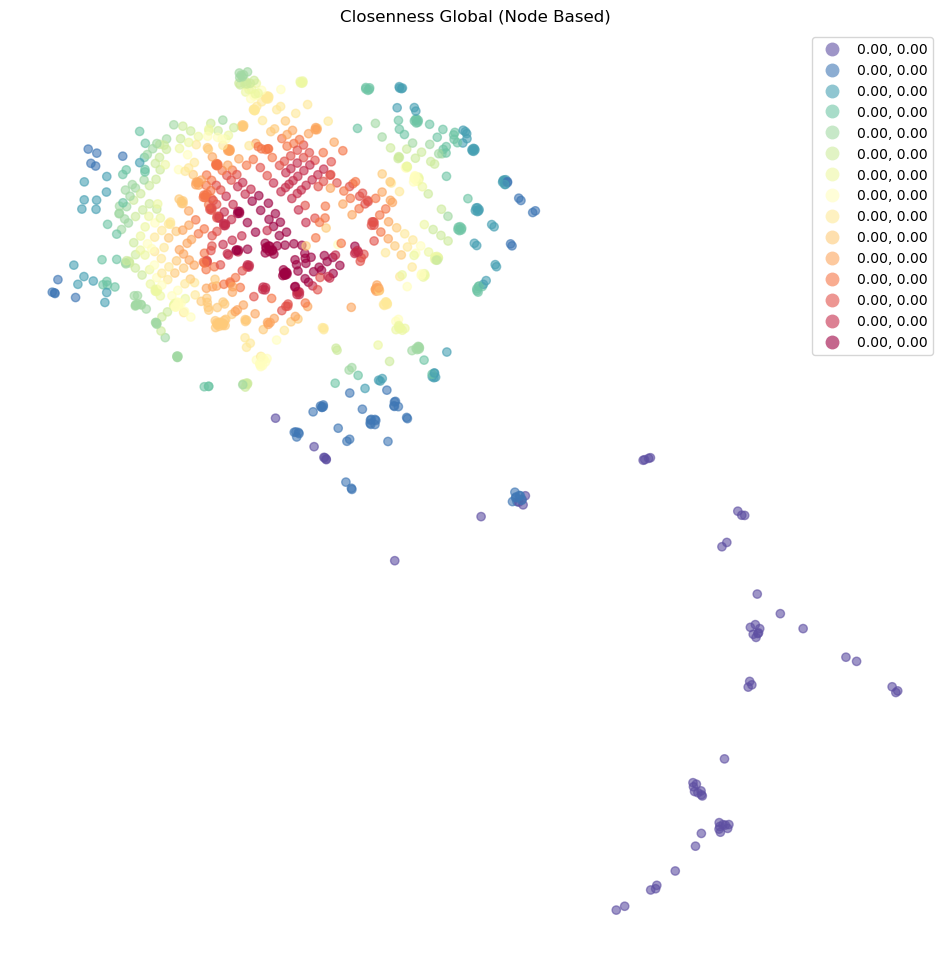

In [14]:
ax = nodes.plot(
    column="closeness_global",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(12, 12),
    legend=True
)
ax.set_axis_off()
ax.set_title("Closenness Global (Node Based)")

In [15]:
mm.mean_nodes(closeness, "closeness_global")

In [16]:
primal_gdf_clos = mm.nx_to_gdf(closeness, points=False)
primal_gdf_clos.head()

,segment_id,highway,name,length,db_day,db_evening,db_night,noise_day,noise_evening,noise_night,distance,geometry,width,openness,width_deviation,mm_len,closeness_global
0,206378333_6315715548_0,residential,"['Camí de la Via', 'Passatge de les Feixes Roca']",308.730134,68,65,61,3,3,3,381.651447,"LINESTRING (417459.73 4573025.45, 417476.559 4...",35.176945,0.590909,4.046847,309.140437,0.000324
1,6315715548_206378333_0,residential,"['Camí de la Via', 'Passatge de les Feixes Roca']",308.730134,68,65,61,3,3,3,381.651447,"LINESTRING (417727.694 4573070.599, 417675.592...",35.402010,0.575758,4.142431,309.140437,0.000324
2,2383446335_206378333_0,residential,Carrer de l'Enginy,167.878854,68,65,61,3,3,3,399.309198,"LINESTRING (417593.203 4572924.851, 417587.219...",34.320234,0.600000,0.181410,168.031053,0.000313
3,4469422084_6315715548_0,residential,Carrer d'Hipàcia,67.335323,70,67,61,4,3,3,358.633354,"LINESTRING (417780.484 4573112.116, 417775.314...",50.000000,1.000000,NaN,67.386480,0.000344
4,6315715548_2383446364_0,residential,Carrer d'Hipàcia,189.132682,70,67,61,4,3,3,484.608105,"LINESTRING (417727.694 4573070.599, 417704.878...",37.381258,0.545455,2.855489,189.139324,0.000330


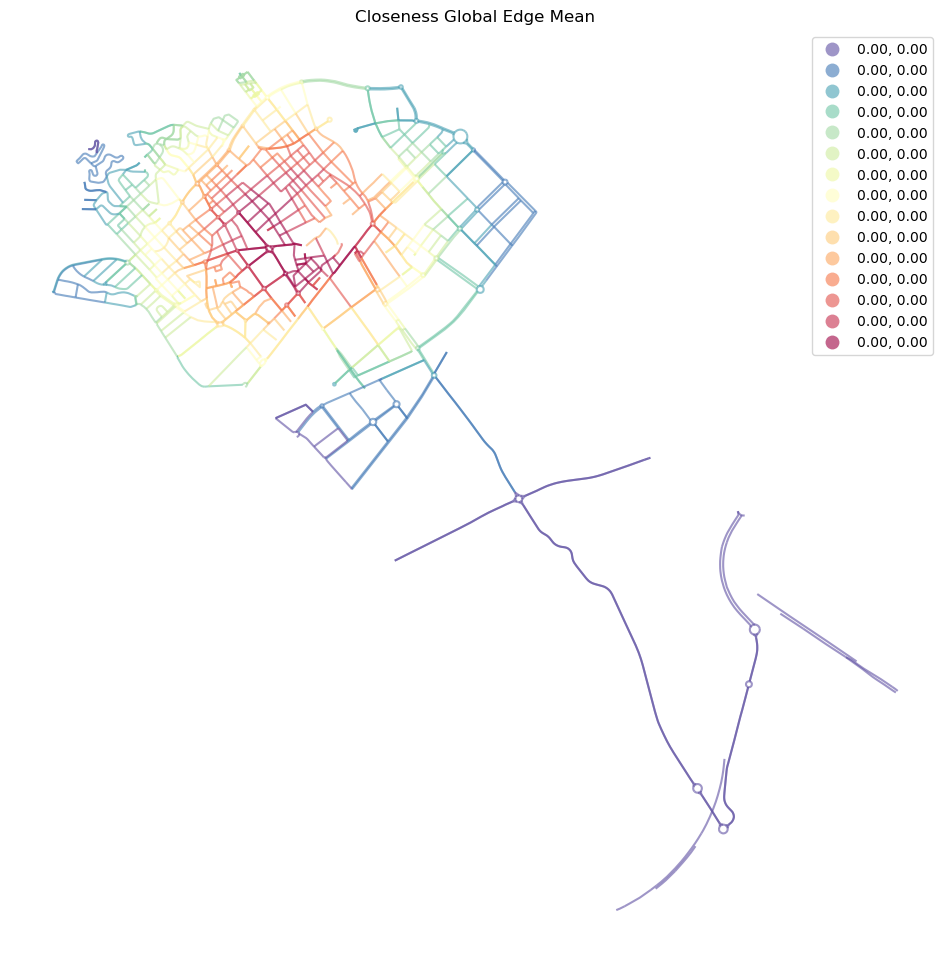

In [17]:

ax = primal_gdf_clos.plot(
    column="closeness_global",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(12, 12),
    legend=True
)
ax.set_axis_off()
_ = ax.set_title("Closeness Global Edge Mean")

## Local Closeness Centrality

In [18]:
local_clos = mm.closeness_centrality(
    primal, radius=400, name='closeness400', distance='mm_len', weight='mm_len'
)

  0%|          | 0/933 [00:00<?, ?it/s]

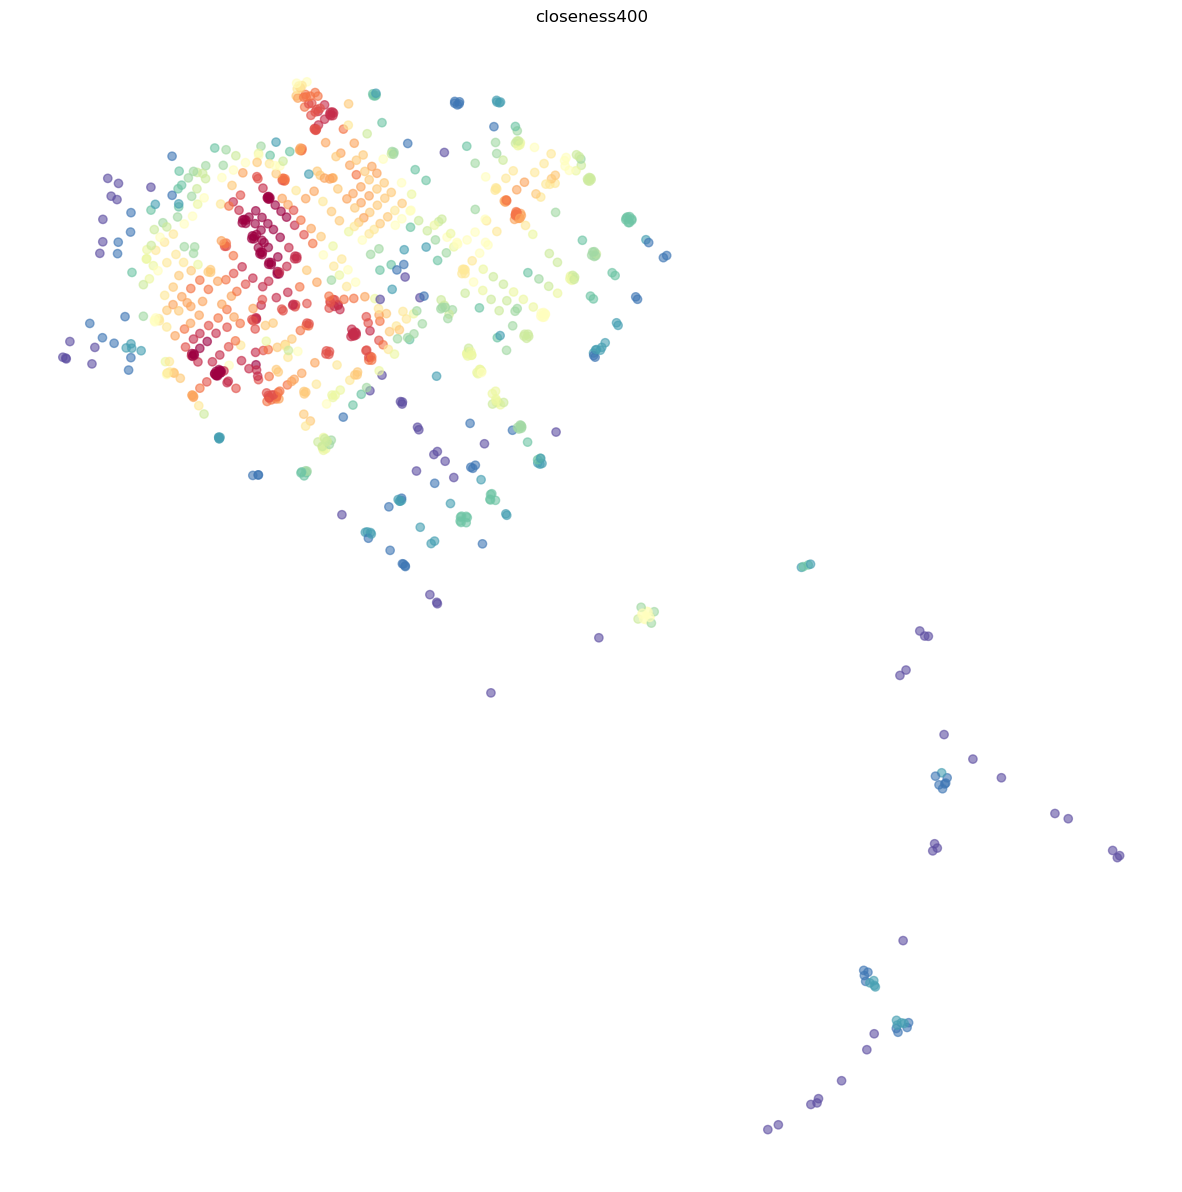

In [19]:
nodes = mm.nx_to_gdf(local_clos, lines=False)
ax = nodes.plot(
    column="closeness400",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(15, 15),
)
ax.set_axis_off()
_ = ax.set_title("closeness400")

In [20]:
mm.mean_nodes(local_clos, "closeness400")

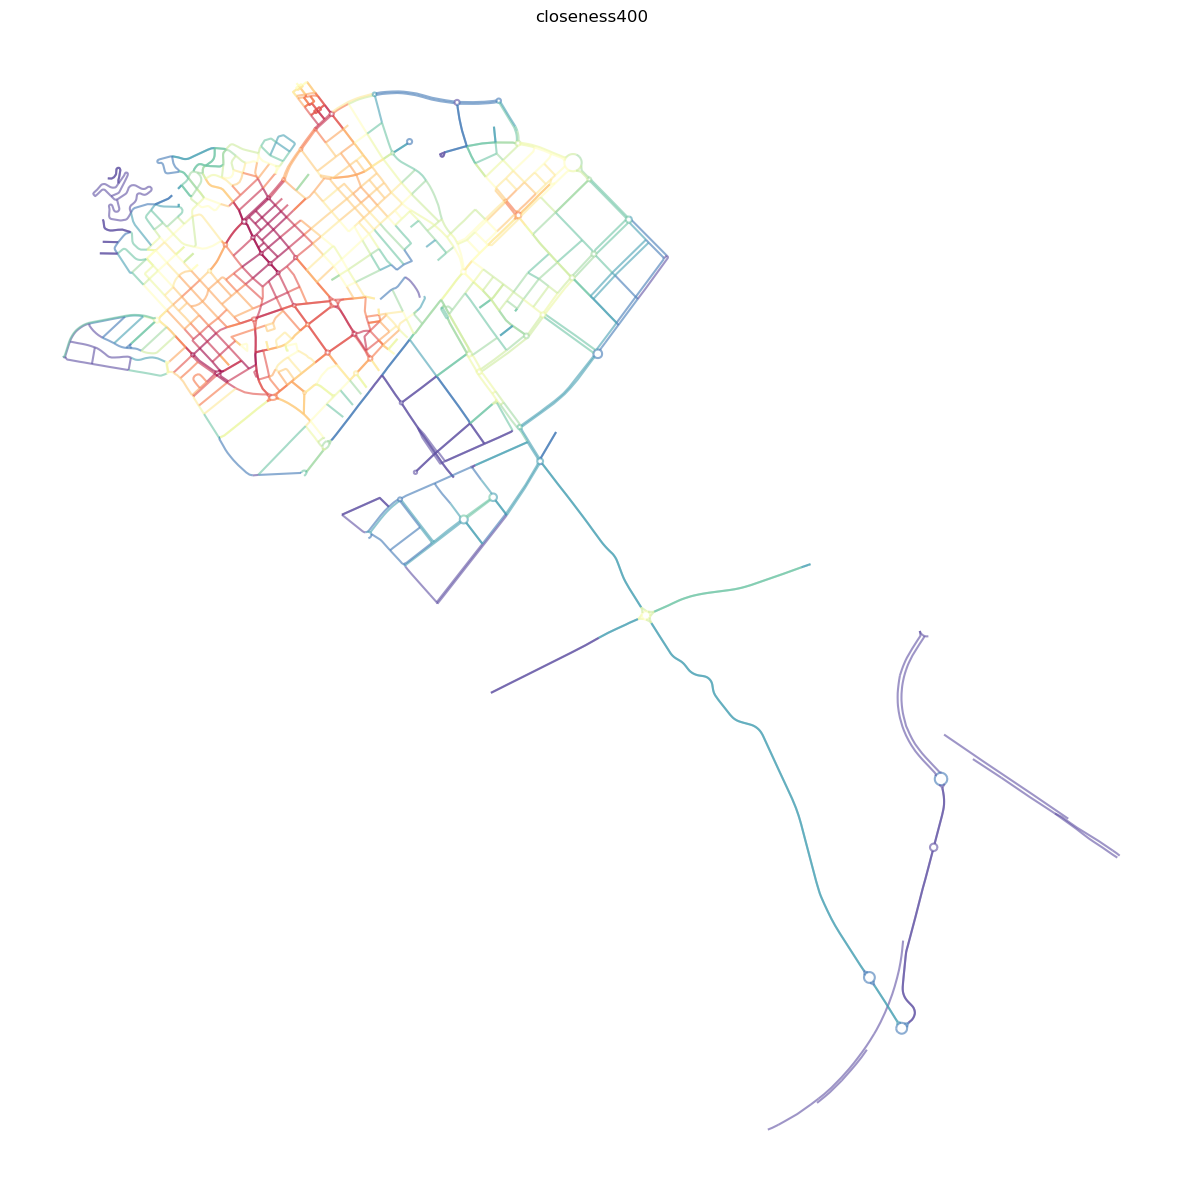

In [21]:
primal_gdf_clos400 = mm.nx_to_gdf(local_clos, points=False)

ax = primal_gdf_clos400.plot(
    column="closeness400",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(15, 15),
)
ax.set_axis_off()
_ = ax.set_title("closeness400")

## Straightness

In [22]:
straighteness = mm.straightness_centrality(
    primal
)

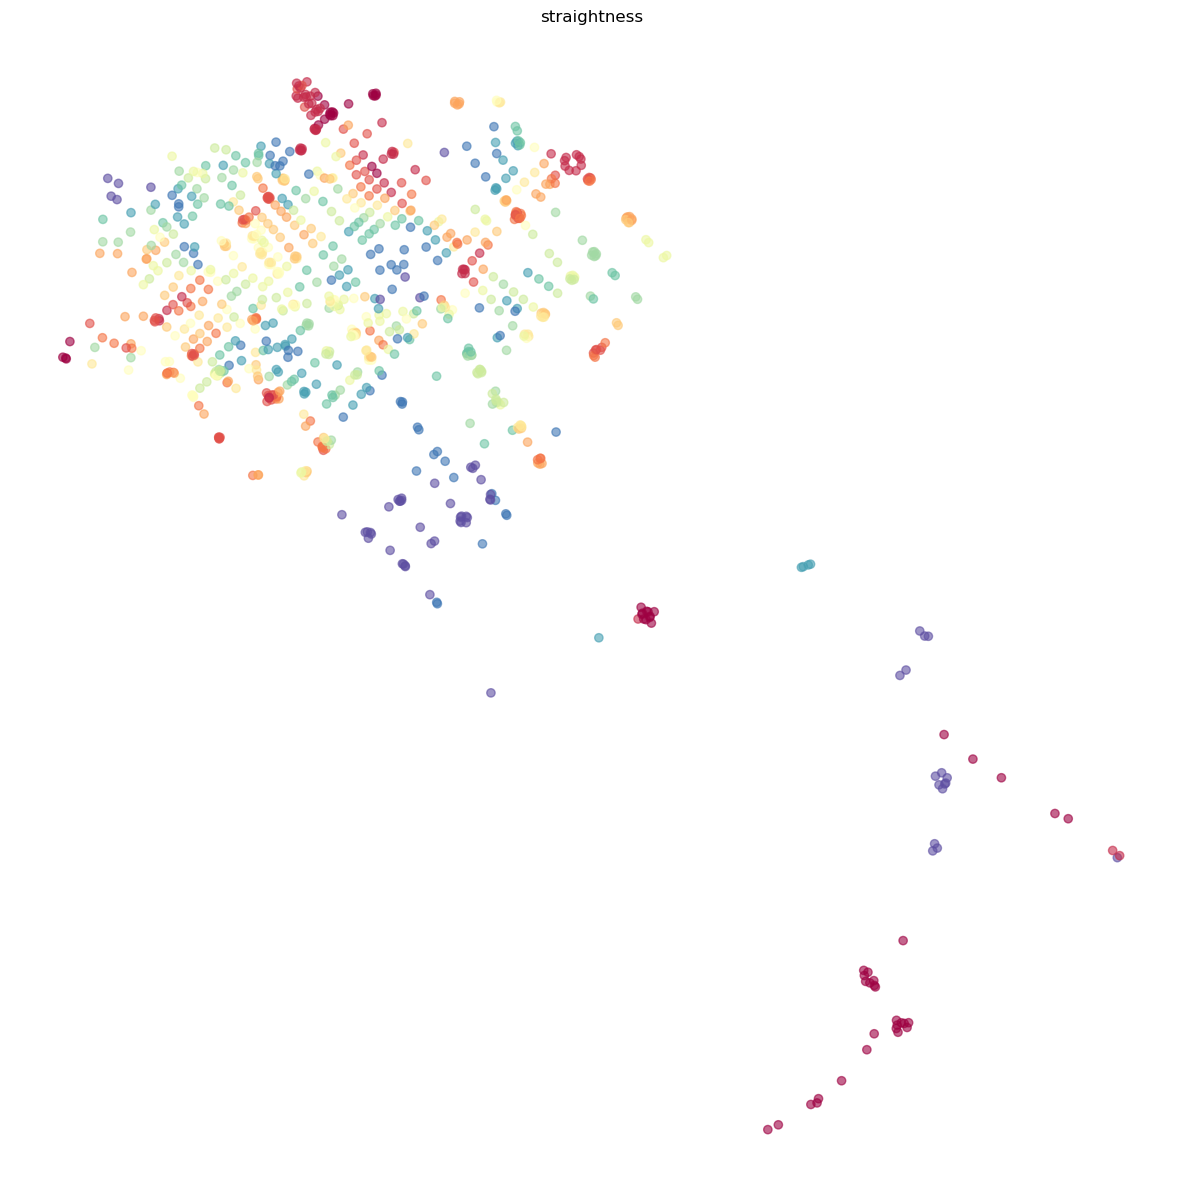

In [23]:
nodes = mm.nx_to_gdf(straighteness, lines=False)
ax = nodes.plot(
    column="straightness",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(15, 15),
)
ax.set_axis_off()
_ = ax.set_title("straightness")

In [24]:
mm.mean_nodes(straighteness, "straightness")

In [25]:
primal_gdf_str = mm.nx_to_gdf(straighteness, points=False)
primal_gdf_str.head()

,segment_id,highway,name,length,db_day,db_evening,db_night,noise_day,noise_evening,noise_night,distance,geometry,width,openness,width_deviation,mm_len,straightness
0,206378333_6315715548_0,residential,"['Camí de la Via', 'Passatge de les Feixes Roca']",308.730134,68,65,61,3,3,3,381.651447,"LINESTRING (417459.73 4573025.45, 417476.559 4...",35.176945,0.590909,4.046847,309.140437,0.552232
1,6315715548_206378333_0,residential,"['Camí de la Via', 'Passatge de les Feixes Roca']",308.730134,68,65,61,3,3,3,381.651447,"LINESTRING (417727.694 4573070.599, 417675.592...",35.402010,0.575758,4.142431,309.140437,0.552232
2,2383446335_206378333_0,residential,Carrer de l'Enginy,167.878854,68,65,61,3,3,3,399.309198,"LINESTRING (417593.203 4572924.851, 417587.219...",34.320234,0.600000,0.181410,168.031053,0.554033
3,4469422084_6315715548_0,residential,Carrer d'Hipàcia,67.335323,70,67,61,4,3,3,358.633354,"LINESTRING (417780.484 4573112.116, 417775.314...",50.000000,1.000000,NaN,67.386480,0.572286
4,6315715548_2383446364_0,residential,Carrer d'Hipàcia,189.132682,70,67,61,4,3,3,484.608105,"LINESTRING (417727.694 4573070.599, 417704.878...",37.381258,0.545455,2.855489,189.139324,0.573152


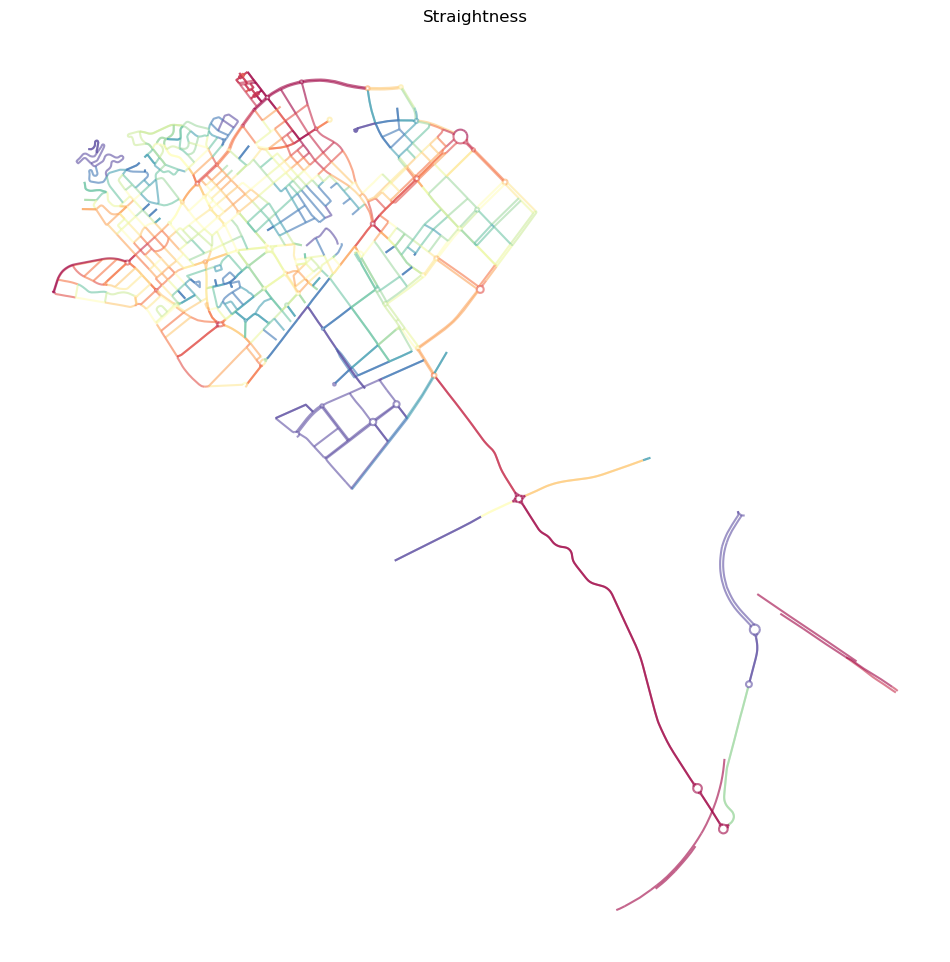

In [26]:
ax = primal_gdf_str.plot(
    column="straightness",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(12, 12),
)
ax.set_axis_off()
_ = ax.set_title("Straightness")

## Create data frame

In [27]:
dataset = edges[['segment_id', 'width', 'openness']].copy()

dataset = (
    dataset
    .merge(primal_gdf_betw[['segment_id', 'betweenness_metric_e']], on='segment_id', how='left')
    .merge(primal_gdf_clos[['segment_id', 'closeness_global']], on='segment_id', how='left')
    .merge(primal_gdf_clos400[['segment_id', 'closeness400']], on='segment_id', how='left')
    .merge(primal_gdf_str[['segment_id', 'straightness']], on='segment_id', how='left')
    .rename(columns={
        'segment_id': 'road_id',
        'betweenness_metric_e': 'betweenness',
        'closeness400': 'closeness_400'
    })
    .fillna(0)
)

dataset.head()

,road_id,width,openness,betweenness,closeness_global,closeness_400,straightness
0,206378333_6315715548_0,35.176945,0.590909,0.002059,0.000324,0.000058,0.552232
1,208568922_208568921_0,50.000000,1.000000,0.000005,0.000008,0.000007,0.998369
2,208568926_208568922_1,50.000000,1.000000,0.000005,0.000009,0.000008,0.998353
3,208595138_208595144_0,50.000000,1.000000,0.000012,0.000007,0.000000,0.979284
4,208595144_2332249073_0,50.000000,1.000000,0.000018,0.000010,0.000007,0.991167


## Export dataset to CSV

In [28]:
import os
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, "momepy_roads_features.csv"), index=False)
print("Exported momepy_roads_features.csv")

Exported momepy_roads_features.csv
